<a href="https://colab.research.google.com/github/Noga32/NatuClean-NLP-Explorer/blob/main/Procesamiento_de_Lenguaje_Natural_(NLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Trabajo en Grupo
Grupo N*4
Brandon Acurio
Hugo Benavides
Jhoel Ramirez
Katherine Cabrera
Bryan Andrade
Jordy Caranqui
Edgar Vargas



Visualizador de analogias semanticas con Gensim

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



--- EVALUACIÓN DEL MODELO ---
ia - modelo: no disponible
datos - pipeline: 0.0985 | esperado: 1
chatbot - usuario: -0.0189 | esperado: 1
modelo - zapato: no disponible
Similitud IA - modelo: None
Vecinos de 'pipeline': [('adoptar', 0.35373273491859436), ('tdsp', 0.3109327256679535), ('usuario', 0.2923862040042877), ('embargo', 0.26673898100852966), ('servidor', 0.26600348949432373), ('crispdm', 0.26477426290512085), ('mlopsempaquetado', 0.2585145831108093), ('detectar', 0.2564351260662079), ('conjuntamente', 0.2339702844619751), ('sados', 0.22957473993301392)]


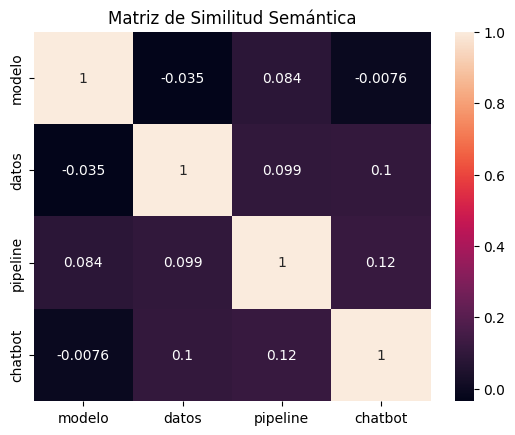

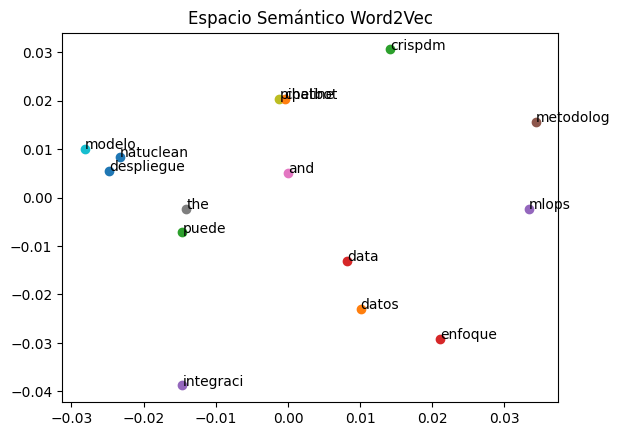

Modelo guardado correctamente

--- ANÁLISIS DEL DOCUMENTO ---
CRISP: [('significativamente', 0.32338258624076843), ('mediante', 0.2934618294239044), ('architecturekeywords', 0.28672686219215393), ('grandes', 0.26176872849464417), ('journal', 0.25687187910079956), ('seis', 0.25482434034347534), ('exhaustive', 0.2436673939228058), ('monitoreo', 0.2345954328775406), ('virtual', 0.22611171007156372), ('you', 0.2211058884859085)]
mlops: [('enfoque', 0.3146519660949707), ('figura', 0.30790072679519653), ('evaluaci', 0.2892392873764038), ('producci', 0.2673451602458954), ('crispdm', 0.257169246673584), ('kreuzberger', 0.2544979155063629), ('aplicaci', 0.25322917103767395), ('science', 0.24438002705574036), ('conclusiones', 0.23895108699798584), ('subconjunto', 0.2368515580892563)]
pipeline: [('adoptar', 0.35373273491859436), ('tdsp', 0.3109327256679535), ('usuario', 0.2923862040042877), ('embargo', 0.26673898100852966), ('servidor', 0.26600348949432373), ('crispdm', 0.26477426290512085), ('ml

In [ ]:
# Implementación de un modelo Word2Vec entrenado sobre un PDF técnico de la misma materia sobre las diversas metodologias de desarrollo IA
# para analizar relaciones semánticas en el dominio de IA.
# Para este caso se instalo la herramienta Gensim segun lo acrodado por el inge pero tambien porque este permite la implemnatcion de
#Word2Vec, para el procesamiento del lenguaje natural NLTK, para la extraccion del texto desde el PDF se uso PyPDF2, para la
#reduccion de dimensiones a 2D y sus mtericas se usa sklearn y matplotlib para la visualizacion
!pip install gensim nltk PyPDF2 scikit-learn matplotlib seaborn
# 2.LIBRERÍAS
import re
import nltk
import PyPDF2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Primero descargar de recursos lingüísticos necesarios para poder entender el pdf, las stopwords son innecesarias
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Segundo es la extraccion de la informacion del PDF pues este permite usar documento reales para alimentar el dataset
# ademas de permitir la simulacion de escenarios reales como reportes
#IMPORTANTE NO USAR PDF ESCANEADOS
def leer_pdf(ruta_pdf):
    """
    Extrae texto completo desde un archivo PDF.
    """
    texto = ""
    with open(ruta_pdf, 'rb') as archivo:
        lector = PyPDF2.PdfReader(archivo)
        for pagina in lector.pages:
            texto += pagina.extract_text()
    return texto

# Tercero es el procesamiento del texto y sualmente se limpia para eliminar ruido, esto implica la conversion del texto a minusculas
#elimina los caracteres no alfabeticos asi como reduce la dimension del vocabulario y mejora el embedding
def limpiar_texto(texto):
    """
    Normaliza el texto eliminando ruido.
    """
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñ\s]', '', texto)
    return texto
#en el mismo tambien se porcede a hacer tokens para convertir el texto en listas de palabras por oracion, importante para el uso de Word2Vec
#pues este necesita conexto por oraciones y eliminar las stopwords

def tokenizar_oraciones(texto):
    """
    Convierte el texto en listas de palabras por oración.
    """

    oraciones = sent_tokenize(texto)
    stop_words = set(stopwords.words('spanish'))

    dataset = []

    for oracion in oraciones:
        palabras = word_tokenize(oracion)

        # Eliminación de palabras irrelevantes
        palabras = [
            w for w in palabras
            if w not in stop_words and len(w) > 2
        ]

        if len(palabras) > 2:
            dataset.append(palabras)

    return dataset
# Para el siguiente paso pasamos al entrenamiento del modelo Word2Vec donde definimos el tamanio del vector, su window, y el skip-gram paraaa
# mejor semantica y su uso es porque el dataset es pequenio a maximo mediano como el documento PDF
def entrenar_word2vec(dataset):
    """
    Entrena el modelo Word2Vec.

    Parámetros clave:
    - vector_size=100 → dimensión del embedding
    - window=5 → contexto local
    - sg=1 → Skip-gram (mejor semántica)
    """

    modelo = Word2Vec(
        sentences=dataset,
        vector_size=100,
        window=5,
        min_count=1,
        workers=4,
        sg=1
    )

    return modelo
# Tambien se decidio usar mnetricas para la evaluacion del modelo y su cumplimiento a traves del uso del calculo de similitud coseno entre pabaras,
#esto implica que si es 1 estas son muy similares y si es 0 no tienen relacion
# ------------------------------------------------------------
def similitud(modelo, palabra1, palabra2):
    """
    """
    try:
        return modelo.wv.similarity(palabra1, palabra2)
    except:
        return None
#Asi mismo se difinio los vecinos semanticos que estos son por la palabra mas cercana en el espacio vectorial lo que valida la coherencia del modelo

def vecinos_semanticos(modelo, palabra):
    """
    Obtiene palabras más cercanas en el espacio vectorial.
    """
    try:
        return modelo.wv.most_similar(palabra)
    except:
        return []
#Por ultimo en esta se hac la matirz de similitud para analizar globalmente el espacio semantico

def matriz_similitud(modelo, palabras):
    """
    Genera matriz de similitud entre múltiples palabras.
    """
    vectores = [modelo.wv[w] for w in palabras if w in modelo.wv]
    return cosine_similarity(vectores)
# Por ultimo antes de ingresar al pipeline se hace la reduccion de dimensiones con PCA y se grafica los embeddings pues esto permite la
#interpretacion humana de las relaciones semanticas
def visualizar_embeddings(modelo, palabras):
    """
    Reduce dimensionalidad con PCA y grafica embeddings.
    """

    vectores = [modelo.wv[w] for w in palabras]

    pca = PCA(n_components=2)
    resultado = pca.fit_transform(vectores)

    plt.figure()
    for i, palabra in enumerate(palabras):
        plt.scatter(resultado[i, 0], resultado[i, 1])
        plt.text(resultado[i, 0], resultado[i, 1], palabra)

    plt.title("Espacio Semántico Word2Vec")
    plt.show()


# Por ultimo el desarrollo del pipeline

# Cargar PDF
texto = leer_pdf("7305_Chatboty_de_NatuClean (1).pdf")

# Preprocesar
texto_limpio = limpiar_texto(texto)
dataset = tokenizar_oraciones(texto_limpio)

# Entrenar modelo
modelo = entrenar_word2vec(dataset)
# 9Evaluacion del modelo para ver la calidad semantica

def evaluar_modelo(modelo):
    """
    """

    print("\n--- EVALUACIÓN DEL MODELO ---")

    pruebas = [
        ("ia", "modelo", 1),
        ("datos", "pipeline", 1),
        ("chatbot", "usuario", 1),
        ("modelo", "zapato", 0)
    ]

    for w1, w2, esperado in pruebas:
        try:
            sim = modelo.wv.similarity(w1, w2)
            print(f"{w1} - {w2}: {sim:.4f} | esperado: {esperado}")
        except:
            print(f"{w1} - {w2}: no disponible")

evaluar_modelo(modelo)
# Evaluación
print("Similitud IA - modelo:", similitud(modelo, "ia", "modelo"))
print("Vecinos de 'pipeline':", vecinos_semanticos(modelo, "pipeline"))
# MATRIZ DE SIMILITUD SEMÁNTICA

palabras_clave = ["ia", "modelo", "datos", "pipeline", "chatbot"]

palabras_validas = [w for w in palabras_clave if w in modelo.wv]

vectores = [modelo.wv[w] for w in palabras_validas]

sim_matrix = cosine_similarity(vectores)

plt.figure()
sns.heatmap(sim_matrix,
            xticklabels=palabras_validas,
            yticklabels=palabras_validas,
            annot=True)

plt.title("Matriz de Similitud Semántica")
plt.show()
# Visualización
palabras = list(modelo.wv.index_to_key)[:15]
visualizar_embeddings(modelo, palabras)
#Guardar el modelo para el uso en steamlit
modelo.save("modelo_word2vec.model")
print("Modelo guardado correctamente")
print("\n--- ANÁLISIS DEL DOCUMENTO ---")

print("CRISP:", modelo.wv.most_similar("crisp"))
print("mlops:", modelo.wv.most_similar("mlops"))
print("pipeline:", modelo.wv.most_similar("pipeline"))

In [ ]:
#USO DEL STEAMLIT PARA FUNCIONALIDAD
!pip install streamlit
import streamlit as st
from gensim.models import Word2Vec

# Cargar modelo
modelo = Word2Vec.load("modelo_word2vec.model")

st.title("Explorador Semántico de IA")

st.markdown("Modelo entrenado con documento técnico sobre arquitecturas de IA")

# SIMILITUD
st.header("Similitud entre palabras")

w1 = st.text_input("Palabra 1")
w2 = st.text_input("Palabra 2")

if st.button("Calcular similitud"):
    try:
        sim = modelo.wv.similarity(w1, w2)
        st.success(f"Similitud: {sim:.4f}")
    except:
        st.error("Error en palabras")

# PALABRAS SIMILARES
st.header("Palabras similares")

palabra = st.text_input("Palabra base")

if palabra:
    try:
        similares = modelo.wv.most_similar(palabra)
        st.write(similares)
    except:
        st.error("No encontrada")

# ANALOGÍAS
st.header("Analogías")

p1 = st.text_input("Positivo 1")
p2 = st.text_input("Positivo 2")
n1 = st.text_input("Negativo")

if st.button("Resolver analogía"):
    try:
        resultado = modelo.wv.most_similar(
            positive=[p1, p2],
            negative=[n1]
        )
        st.write(resultado)
    except:
        st.error("Error")

#El modelo fue entrenado sobre un documento técnico real, y su calidad se validó
#mediante métricas de similitud, coherencia semántica y visualización. Además, se implementó una interfaz
#interactiva que permite explorar dinámicamente el conocimiento aprendido.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 31.8 MB/s eta 0:00:00


2026-04-06 22:25:21.227 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 22:25:21.505 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-06 22:25:21.506 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 22:25:21.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 22:25:21.510 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 22:25:21.512 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 22:25:21.513 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-06 22:25:21.515 Thread 'MainThread': mi

In [ ]:
%%writefile app.py
import streamlit as st
from gensim.models import Word2Vec

# Cargar modelo
modelo = Word2Vec.load("modelo_word2vec.model")

st.title("Explorador Semántico de IA")

st.markdown("Modelo entrenado con documento técnico sobre arquitecturas de IA")

# SIMILITUD
st.header("Similitud entre palabras")

w1 = st.text_input("Palabra 1")
w2 = st.text_input("Palabra 2")

if st.button("Calcular similitud"):
    try:
        sim = modelo.wv.similarity(w1, w2)
        st.success(f"Similitud: {sim:.4f}")
    except:
        st.error("Error en palabras")

# PALABRAS SIMILARES
st.header("Palabras similares")

palabra = st.text_input("Palabra base")

if palabra:
    try:
        similares = modelo.wv.most_similar(palabra)
        st.write(similares)
    except:
        st.error("No encontrada")

# ANALOGÍAS
st.header("Analogías")

p1 = st.text_input("Positivo 1")
p2 = st.text_input("Positivo 2")
n1 = st.text_input("Negativo")

if st.button("Resolver analogía"):
    try:
        resultado = modelo.wv.most_similar(
            positive=[p1, p2],
            negative=[n1]
        )
        st.write(resultado)
    except:
        st.error("Error")

#El modelo fue entrenado sobre un documento técnico real, y su calidad se validó
#mediante métricas de similitud, coherencia semántica y visualización. Además, se implementó una interfaz
#interactiva que permite explorar dinámicamente el conocimiento aprendido.

Writing app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.23.71.186:8501

  Stopping...
^C
